<a href="https://colab.research.google.com/github/Innotech-Manipal-TP26/Ananyaraj2ndYear/blob/main/Week5/DLNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from collections import Counter
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [3]:
dataset = load_dataset("imdb")

train_data = dataset["train"]

texts = list(train_data["text"])
labels = list(train_data["label"])

test_data = dataset["test"]
X_test = list(test_data["text"])
y_test = list(test_data["label"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    texts, labels,
    test_size=0.1,
    random_state=42,
    stratify=labels
)

In [5]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

In [6]:
MAX_VOCAB = 20000
UNK = "<UNK>"
PAD = "<PAD>"

counter = Counter()

for text in X_train:
    counter.update(tokenize(text))

most_common = counter.most_common(MAX_VOCAB - 2)

word2idx = {PAD: 0, UNK: 1}

for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

vocab_size = len(word2idx)

In [7]:
def encode(text):
    return [word2idx.get(w, 1) for w in tokenize(text)]

In [8]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        idx = int(idx)  # 🔥 FIX

        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float)

        return x, y

In [9]:
def collate_fn(batch):
    texts, labels = zip(*batch)

    lengths = torch.tensor([len(t) for t in texts], dtype=torch.long)

    padded = pad_sequence(
        texts,
        batch_first=True,
        padding_value=word2idx[PAD]
    )

    labels = torch.tensor(labels, dtype=torch.float)

    return padded, lengths, labels

In [10]:
train_ds = IMDBDataset(X_train, y_train)
val_ds = IMDBDataset(X_val, y_val)
test_ds = IMDBDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [11]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        x = self.embedding(x)

        packed = torch.nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        return self.fc(hidden.squeeze(0))

In [13]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        x = self.embedding(x)

        packed = torch.nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed)

        return self.fc(hidden[-1])

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()

In [34]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for x, lengths, y in loader:

        # Move only tensors that must go to GPU
        x = x.to(device)
        y = y.to(device)
        lengths = lengths  # keep on CPU (important for many RNN utils)

        optimizer.zero_grad()

        out = model(x, lengths)

        # safer than squeeze(1)
        out = out.view(-1)

        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [36]:
criterion = torch.nn.BCEWithLogitsLoss()

In [16]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, lengths, y in loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)

            out = model(x, lengths).squeeze(1)
            preds = torch.sigmoid(out) > 0.5

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [18]:
rnn_model = VanillaRNN(vocab_size).to(device)
lstm_model = LSTMModel(vocab_size).to(device)

In [19]:
rnn_train_losses = []
rnn_val_acc = []

for epoch in range(10):
    loss = train(rnn_model, train_loader, optimizer)
    acc = evaluate(rnn_model, val_loader)

    rnn_train_losses.append(loss)
    rnn_val_acc.append(acc)

    print(f"[RNN] Epoch {epoch+1} Loss:{loss:.4f} Val Acc:{acc:.4f}")

[RNN] Epoch 1 Loss:0.7016 Val Acc:0.4840
[RNN] Epoch 2 Loss:0.7016 Val Acc:0.4840
[RNN] Epoch 3 Loss:0.7016 Val Acc:0.4840
[RNN] Epoch 4 Loss:0.7015 Val Acc:0.4840
[RNN] Epoch 5 Loss:0.7016 Val Acc:0.4840
[RNN] Epoch 6 Loss:0.7016 Val Acc:0.4840
[RNN] Epoch 7 Loss:0.7016 Val Acc:0.4840
[RNN] Epoch 8 Loss:0.7015 Val Acc:0.4840
[RNN] Epoch 9 Loss:0.7016 Val Acc:0.4840
[RNN] Epoch 10 Loss:0.7016 Val Acc:0.4840


In [20]:
lstm_train_losses = []
lstm_val_acc = []

for epoch in range(10):
    loss = train(lstm_model, train_loader, optimizer)
    acc = evaluate(lstm_model, val_loader)

    lstm_train_losses.append(loss)
    lstm_val_acc.append(acc)

    print(f"[LSTM] Epoch {epoch+1} Loss:{loss:.4f} Val Acc:{acc:.4f}")

[LSTM] Epoch 1 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 2 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 3 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 4 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 5 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 6 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 7 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 8 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 9 Loss:0.6958 Val Acc:0.4872
[LSTM] Epoch 10 Loss:0.6958 Val Acc:0.4872


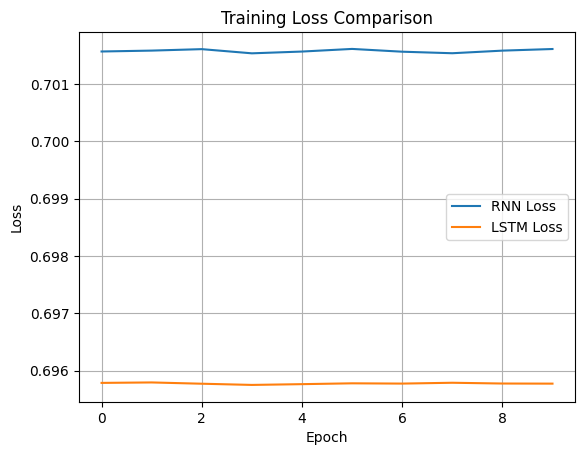

In [21]:
import matplotlib.pyplot as plt

plt.plot(rnn_train_losses, label="RNN Loss")
plt.plot(lstm_train_losses, label="LSTM Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.show()

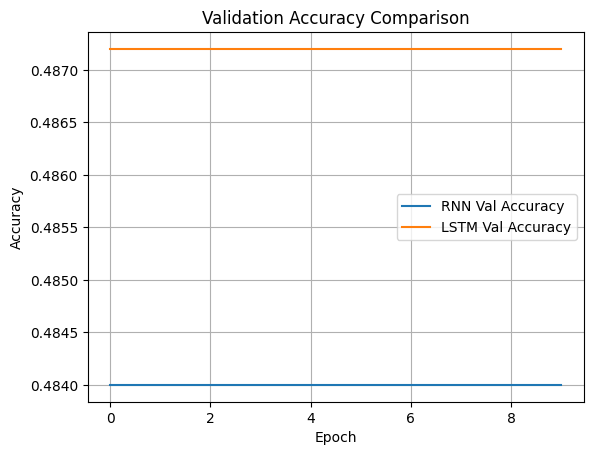

In [22]:
plt.plot(rnn_val_acc, label="RNN Val Accuracy")
plt.plot(lstm_val_acc, label="LSTM Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()
plt.show()

In [45]:
import torch
from torch.utils.data import Dataset

class SeqDataset(Dataset):
    def __init__(self, seq_len, size=5000, vocab_size=2):
        self.seq_len = seq_len
        self.size = size
        self.vocab_size = vocab_size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # sequence of token indices (IMPORTANT: LONG for embedding)
        seq = torch.randint(
            0,
            self.vocab_size,
            (self.seq_len,),
            dtype=torch.long
        )

        # label: 1 if ANY token is 1, else 0
        label = torch.tensor(int((seq == 1).any()), dtype=torch.float32)

        return seq, label

In [ ]:
seq_lengths = [5, 10, 20, ]

In [47]:
for L in seq_lengths:
    print(f"\nTraining seq length: {L}")

    # 🔥 MUST recreate dataset per L
    train_dataset = SeqDataset(L)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

    # model reset per experiment
    rnn_model = VanillaRNN(vocab_size).to(device)

    optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.01)

    acc = train(rnn_model, train_loader, optimizer, criterion, device)

    print(f"[RNN] SeqLen={L} | Val Acc: {acc:.4f}")


Training seq length: 5
[RNN] SeqLen=5 | Val Acc: 0.0461

Training seq length: 10
[RNN] SeqLen=10 | Val Acc: 0.0190

Training seq length: 20
[RNN] SeqLen=20 | Val Acc: 0.0094

Training seq length: 50
[RNN] SeqLen=50 | Val Acc: 0.0122

Training seq length: 100
[RNN] SeqLen=100 | Val Acc: 0.0092

Training seq length: 200
[RNN] SeqLen=200 | Val Acc: 0.0106


In [54]:
for L in seq_lengths:
    print(f"\nTraining seq length: {L}")

    # 🔥 MUST recreate dataset per L
    train_dataset = SeqDataset(L)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

    # model reset per experiment
    lstm_model = LSTMModel(vocab_size).to(device)

    optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.01)

    acc = train(lstm_model, train_loader, optimizer, criterion, device)

    print(f"[RNN] SeqLen={L} | Val Acc: {acc:.4f}")


Training seq length: 5
[RNN] SeqLen=5 | Val Acc: 0.6648

Training seq length: 10
[RNN] SeqLen=10 | Val Acc: 0.7126

Training seq length: 20
[RNN] SeqLen=20 | Val Acc: 0.7363

Training seq length: 50
[RNN] SeqLen=50 | Val Acc: 0.7136

Training seq length: 100
[RNN] SeqLen=100 | Val Acc: 0.6753

Training seq length: 200
[RNN] SeqLen=200 | Val Acc: 0.6946


In [49]:
from sklearn.decomposition import PCA
import numpy as np

embeddings = lstm_model.embedding.weight.detach().cpu().numpy()

In [50]:
words = ["good", "bad", "amazing", "terrible", "boring", "excellent", "awful", "movie"]

indices = [word2idx[w] for w in words if w in word2idx]

selected = embeddings[indices]

In [51]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(selected)

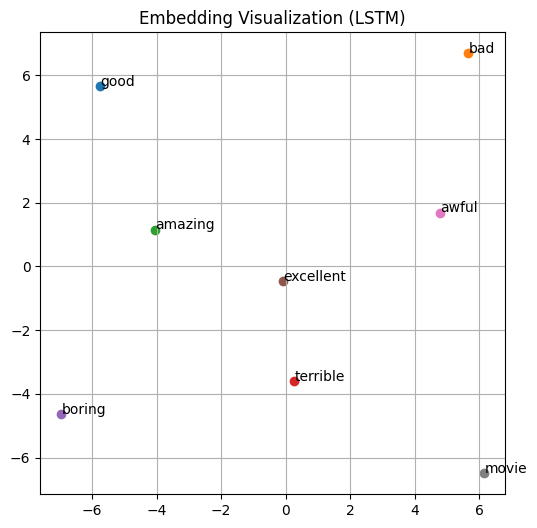

In [52]:
plt.figure(figsize=(6,6))

for i, word in enumerate(words):
    if word in word2idx:
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.text(reduced[i,0]+0.01, reduced[i,1]+0.01, word)

plt.title("Embedding Visualization (LSTM)")
plt.grid()
plt.show()